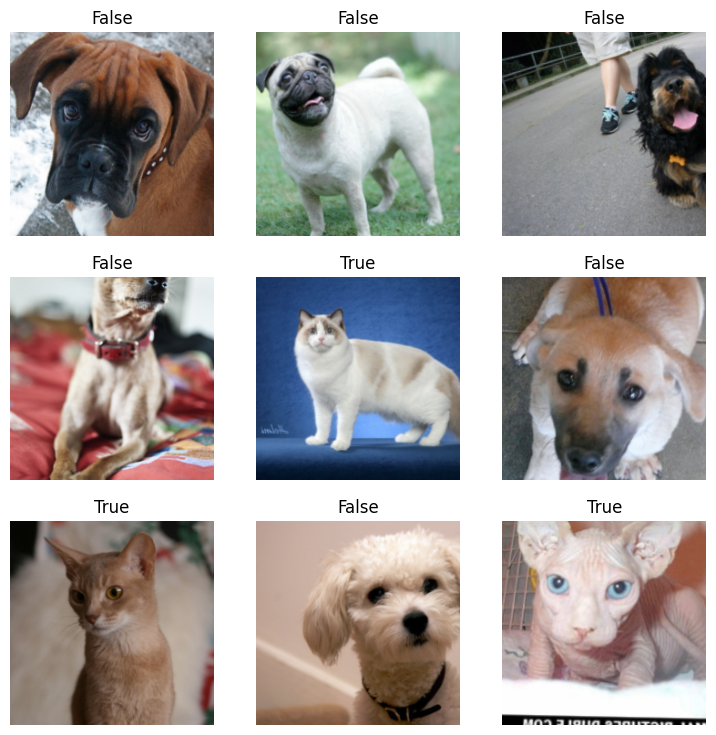

In [16]:
from fastai.vision.all import *

path = untar_data(URLs.PETS)/'images'

def is_cat(x): return Path(x).name[0].isupper()  # ← wrap in Path()

dls = ImageDataLoaders.from_name_func(
    path,
    get_image_files(path),
    valid_pct=0.2,
    label_func=is_cat,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms()
)

dls.show_batch()

In [26]:
learn = vision_learner(dls, resnet34, metrics = error_rate)
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,0.171034,0.020541,0.006766,00:52


epoch,train_loss,valid_loss,error_rate,time
0,0.082631,0.022994,0.008119,00:51
1,0.056496,0.010421,0.002706,00:48
2,0.016289,0.003953,0.002030,00:49


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
learn.export('/content/drive/MyDrive/cat_dog_classifier.pkl')
print("Saved to Google Drive!")

Saved to Google Drive!


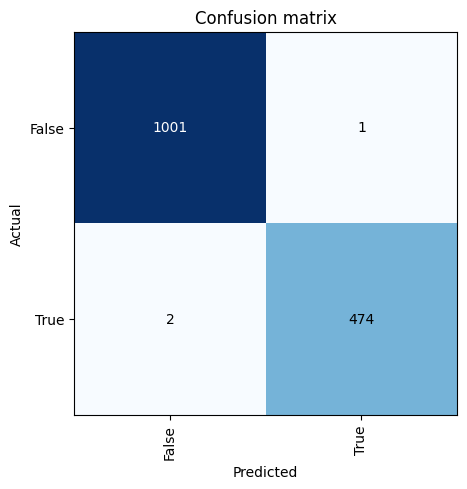

In [20]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

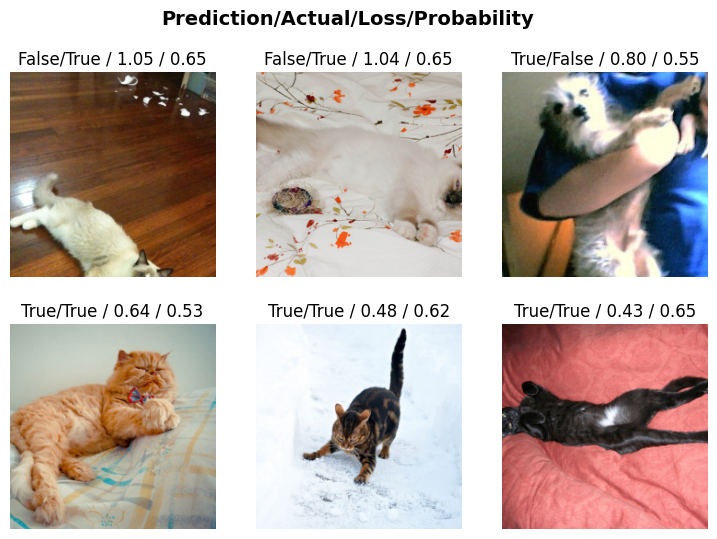

In [21]:
interp.plot_top_losses(6)

In [22]:
learn.export('cat_dog_classifier.pkl')
print("Model saved!")

Model saved!


In [23]:
import os
print(os.listdir())

['.config', '.gradio', 'drive', 'sample_data']


In [27]:
import gradio as gr
from fastai.vision.all import *
import numpy as np

learn = load_learner('/content/drive/MyDrive/cat_dog_classifier.pkl')

def predict(img):
    # Convert to PIL then to fastai format
    from PIL import Image as PILImg
    img = PILImg.fromarray(img.astype('uint8'))
    img = PILImage.create(np.array(img))

    result = learn.predict(img)
    pred = result[0]
    probs = result[2]
    idx = result[1]

    label = 'Cat' if str(pred) == 'True' else 'Dog'
    confidence = float(probs[idx]) * 100
    return f"{label} ({confidence:.1f}% confident)"

app = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="numpy"),  # ← explicitly set type
    outputs=gr.Text(),
    title="Cat vs Dog Classifier",
    description="Upload any photo and AI will tell you if it's a cat or dog!"
)

app.launch(share=True)

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7eb88333ddc966d6b0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
